In [1]:
# ==========================
# Smart Agricultural Production Optimization Engine
# Step 1 : Import Libraries
# ==========================

# Numerical Computation
import numpy as np

# Data Handling
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization Style
plt.style.use('fivethirtyeight')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../dataset/Crop_recommendation.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/Crop_recommendation.csv'

In [4]:
import os

print("Current Working Directory:")
print(os.getcwd())


Current Working Directory:
C:\Users\nagak\Desktop\Opti Crop


In [5]:
import os

print("Files and folders in current directory:")
print(os.listdir())


Files and folders in current directory:
['.ipynb_checkpoints', 'crop_model.pkl', 'data set', 'Untitled1.ipynb']


In [6]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

C:\Users\nagak\Desktop\Opti Crop\data set\Crop_recommendation.csv
C:\Users\nagak\Desktop\Opti Crop\data set\.ipynb_checkpoints\Crop_recommendation.csv-checkpoint.csv


In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\nagak\Desktop\Opti Crop\data set\Crop_recommendation.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [8]:
# Check the number of rows and columns
df.shape


(2200, 8)

In [9]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [10]:
# Statistical summary of numerical columns
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
# Check missing values
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [13]:
# Display column names
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')


In [15]:
df = pd.read_csv("../dataset/Crop_recommendation.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/Crop_recommendation.csv'

In [ ]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()
    

In [ ]:
plt.figure(figsize=(15,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()


In [ ]:
plt.subplot(...)

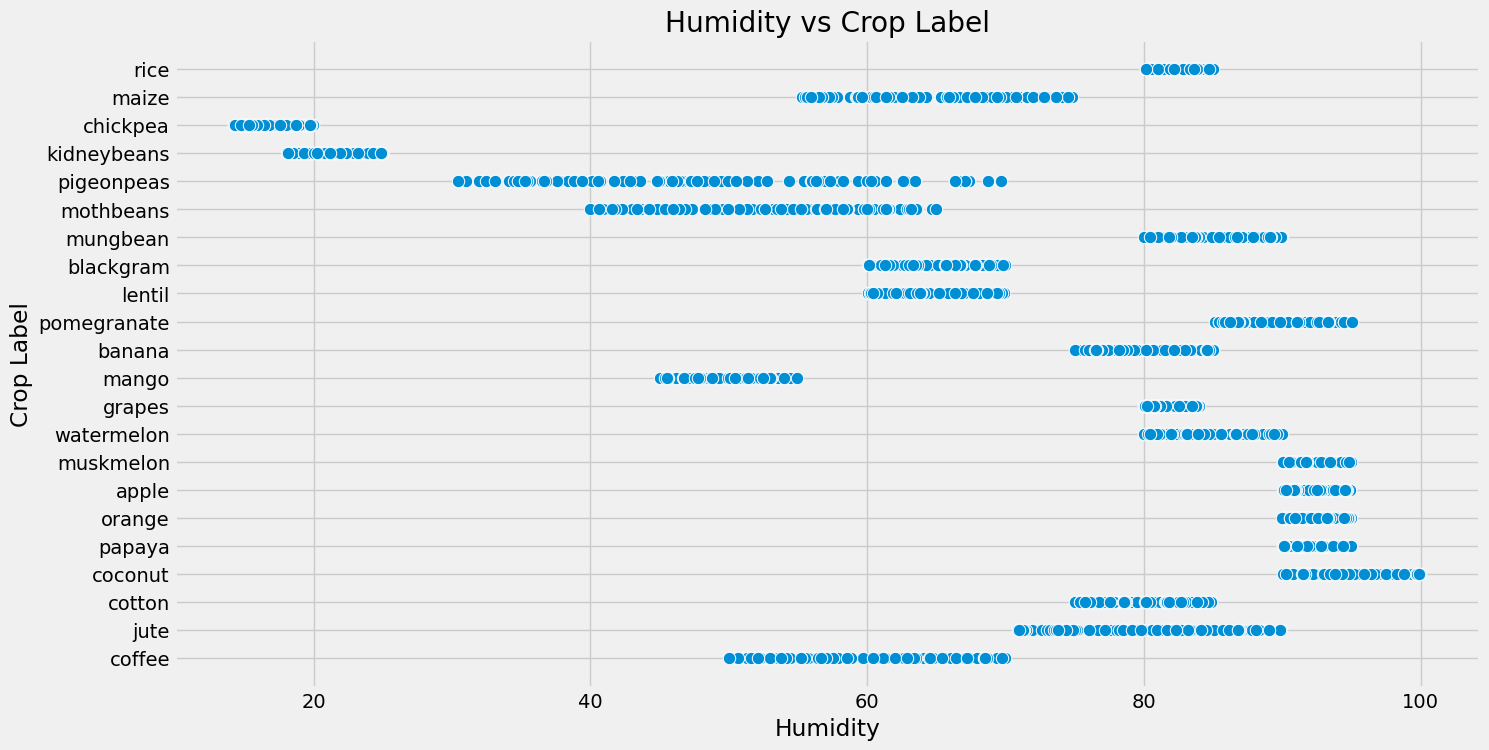

In [16]:
# Bivariate Analysis
# Humidity vs Crop Label

plt.figure(figsize=(15, 8))

sns.scatterplot(
    x='humidity',
    y='label',
    data=df,
    s=80
)

plt.title("Humidity vs Crop Label")
plt.xlabel("Humidity")
plt.ylabel("Crop Label")

plt.show()

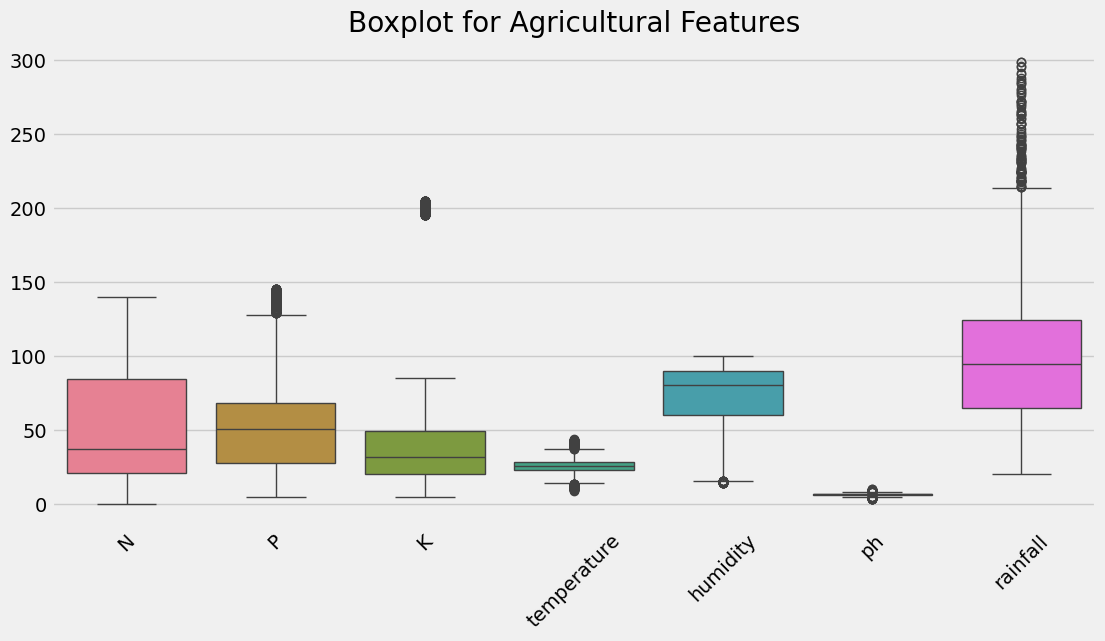

In [17]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['N','P','K','temperature',
                     'humidity','ph','rainfall']])

plt.title("Boxplot for Agricultural Features")
plt.xticks(rotation=45)

plt.show()

In [18]:
# Calculate IQR for Potassium (K)

Q1 = df['K'].quantile(0.25)
Q3 = df['K'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Q1 : 20.0
Q3 : 49.0
IQR : 29.0
Lower Bound : -23.5
Upper Bound : 92.5


In [19]:
outliers = df[(df['K'] < lower_bound) | (df['K'] > upper_bound)]

print("Number of Outliers :", len(outliers))

Number of Outliers : 200


In [20]:
# Log Transformation

df['K_log'] = np.log1p(df['K'])


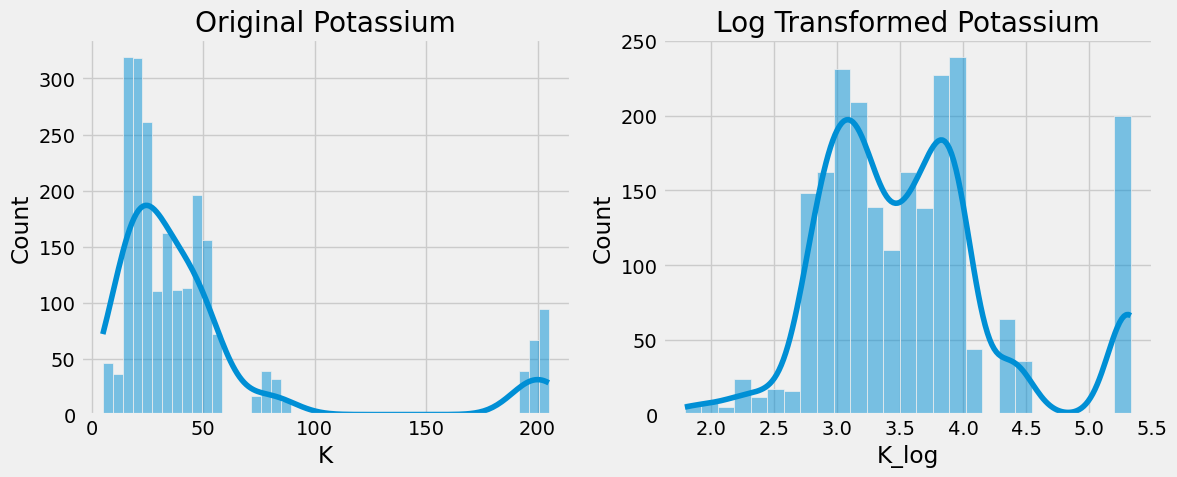

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['K'], kde=True)
plt.title("Original Potassium")

plt.subplot(1,2,2)
sns.histplot(df['K_log'], kde=True)
plt.title("Log Transformed Potassium")

plt.tight_layout()
plt.show()

In [22]:
def season(temp):
    if temp >= 30:
        return "Summer"
    elif temp >= 20:
        return "Rainy"
    else:
        return "Winter"

df["Season"] = df["temperature"].apply(season)

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,K_log,Season
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3.784190,Rainy
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,3.737670,Rainy
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,3.806662,Rainy
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,3.713572,Rainy
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,3.761200,Rainy


In [23]:
# Number of records in each season
print(df["Season"].value_counts())

Season
Rainy     1611
Summer     298
Winter     291
Name: count, dtype: int64


In [24]:
# Crops available in each season
season_crops = df.groupby("Season")["label"].unique()

print(season_crops)

Season
Rainy     [rice, maize, chickpea, kidneybeans, pigeonpea...
Summer    [pigeonpeas, mothbeans, blackgram, mango, grap...
Winter    [maize, chickpea, kidneybeans, pigeonpeas, len...
Name: label, dtype: object


In [25]:
for s in df["Season"].unique():
    print(f"\n{s} Crops:")
    print(df[df["Season"] == s]["label"].unique())


Rainy Crops:
<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

Winter Crops:
<StringArray>
[      'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',      'lentil',
 'pomegranate',      'grapes',      'orange']
Length: 8, dtype: str

Summer Crops:
<StringArray>
['pigeonpeas', 'mothbeans', 'blackgram', 'mango', 'grapes', 'orange',
 'papaya']
Length: 7, dtype: str


In [26]:
import pickle

# best model name example
best_model = rf_model   # replace with your selected model

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved successfully")

NameError: name 'rf_model' is not defined

In [27]:
dir()

['IQR',
 'In',
 'LabelEncoder',
 'Out',
 'Q1',
 'Q3',
 '_',
 '_10',
 '_11',
 '_12',
 '_13',
 '_22',
 '_7',
 '_8',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy_score',
 'classification_report',
 'confusion_matrix',
 'df',
 'dirs',
 'exit',
 'file',
 'files',
 'get_ipython',
 'lower_bound',
 'np',
 'open',
 'os',
 'outliers',
 'pd',
 'pickle',
 'plt',
 'quit',
 'root',
 's',
 'season',
 'season_crops',
 'sns',
 'train_test_split',
 'upper_bound']

In [28]:
import pickle

# best model name example
best_model = rf_model   # replace with your selected model

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved successfully")

NameError: name 'rf_model' is not defined

In [29]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully")

NameError: name 'rf' is not defined

In [30]:
import pickle

with open("crop_model.pkl", "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully")

PermissionError: [Errno 13] Permission denied: 'crop_model.pkl'

In [31]:
import pickle

path = r"C:\Users\Admin\Desktop\crop_model.pkl"

with open(path, "wb") as file:
    pickle.dump(rf, file)

print("Model saved successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\Desktop\\crop_model.pkl'

In [32]:
import os
print(os.getcwd())

C:\Users\nagak\Desktop\Opti Crop


In [33]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'crop_model.pkl', 'data set', 'model.pkl', 'Untitled1.ipynb']


In [34]:
type(rf)


NameError: name 'rf' is not defined

In [35]:
%who

IQR	 LabelEncoder	 Q1	 Q3	 accuracy_score	 classification_report	 confusion_matrix	 df	 dirs	 
file	 files	 lower_bound	 np	 os	 outliers	 path	 pd	 pickle	 
plt	 root	 s	 season	 season_crops	 sns	 train_test_split	 upper_bound	 


In [36]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,K_log,Season
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3.784190,Rainy
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,3.737670,Rainy
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,3.806662,Rainy
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,3.713572,Rainy
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,3.761200,Rainy


In [37]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'K_log', 'Season'],
      dtype='str')

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("Training Completed")

ValueError: could not convert string to float: 'Winter'

In [39]:
import pickle
from sklearn.ensemble import RandomForestClassifier

In [41]:
import pandas as pd

df = pd.read_csv(r"C:\Users\nagak\Desktop\Opti Crop\data set\Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [42]:
import pandas as pd

df = pd.read_csv(r"C:\Users\nagak\Desktop\Opti Crop\data set\Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [43]:
X = df.drop("label", axis=1)
y = df["label"]

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
with open("crop_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully as crop_model.pkl")

PermissionError: [Errno 13] Permission denied: 'crop_model.pkl'

In [48]:
import os
import pickle

save_path = os.path.join(os.getcwd(), "crop_model.pkl")

with open(save_path, "wb") as file:
    pickle.dump(model, file)

print("Saved at:", save_path)

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\nagak\\Desktop\\Opti Crop\\crop_model.pkl'

In [49]:
import os

print(os.path.exists("crop_model.pkl"))
print(os.path.isdir("crop_model.pkl"))

True
True


In [50]:
import pickle

with open("crop_model_new.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [51]:
import pickle
import pandas as pd

# Load the saved model
with open("crop_model_new.pkl", "rb") as file:
    model = pickle.load(file)

# Sample input
input_data = pd.DataFrame({
    "N": [90],
    "P": [42],
    "K": [43],
    "temperature": [20.87],
    "humidity": [82.00],
    "ph": [6.50],
    "rainfall": [202.93]
})

# Predict crop
prediction = model.predict(input_data)

print("Recommended Crop:", prediction[0])

Recommended Crop: rice


In [53]:
# -------------------------------
# Crop Recommendation Prediction
# -------------------------------

import numpy as np
import pandas as pd
import pickle

# Load the trained model
with open("crop_model_new.pkl", "rb") as file:
    model = pickle.load(file)

# Input values
N = 90
P = 42
K = 43
temperature = 20.87
humidity = 82.00
ph = 6.50
rainfall = 202.93

# Create DataFrame
input_data = pd.DataFrame({
    'N': [N],
    'P': [P],
    'K': [K],
    'temperature': [temperature],
    'humidity': [humidity],
    'ph': [ph],
    'rainfall': [rainfall]
})

# Predict crop
prediction = model.predict(input_data)

# Display result
print("===================================")
print("      CROP RECOMMENDATION")
print("===================================")
print(f"Nitrogen (N)      : {N}")
print(f"Phosphorus (P)    : {P}")
print(f"Potassium (K)     : {K}")
print(f"Temperature (°C)  : {temperature}")
print(f"Humidity (%)      : {humidity}")
print(f"Soil pH           : {ph}")
print(f"Rainfall (mm)     : {rainfall}")
print("-----------------------------------")
print("Recommended Crop :", prediction[0])
print("===================================")

      CROP RECOMMENDATION
Nitrogen (N)      : 90
Phosphorus (P)    : 42
Potassium (K)     : 43
Temperature (°C)  : 20.87
Humidity (%)      : 82.0
Soil pH           : 6.5
Rainfall (mm)     : 202.93
-----------------------------------
Recommended Crop : rice
